In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [2]:
class batsmanstat(TypedDict):
    runs : int
    balls: int
    four: int
    sixes : int

    sr:float
    bpb:float
    boundary:float
    summary :str

In [3]:
def calculate_sr(state:batsmanstat):
     sr =(state['runs']/state['balls'])*100
     state['sr']=sr
     return {'sr' : sr}

In [4]:
def calculate_bpb(state:batsmanstat):
    total= state['four']+state['sixes']
    bpb= total/state['balls']
    return {'bpb' : bpb}

In [5]:
def calculate_boundary(state:batsmanstat):
    four_runs= state['four'] *4
    six_runs= state['sixes']* 6
    total= four_runs+six_runs
    percent= (total/state['runs']) *100
    
    return {'boundary': percent}
    

In [6]:
def calculate_summary(state:batsmanstat)-> batsmanstat:
    summary = f"""
    Strike Rate -> {state['sr']} \n
    Boundary per ball -> {state['bpb']}\n
    Boundary percentage -> {state['boundary']}
    """
    state['summary']= summary

In [7]:
graph= StateGraph(batsmanstat)
graph.add_node('calculate_sr',calculate_sr)
graph.add_node('calculate_bpb',calculate_bpb)
graph.add_node('calculate_boundary',calculate_boundary)
graph.add_node('calculate_summary',calculate_summary)


graph.add_edge(START,'calculate_sr')
graph.add_edge(START,'calculate_bpb')
graph.add_edge(START,'calculate_boundary')
graph.add_edge('calculate_sr' , 'calculate_summary')
graph.add_edge('calculate_bpb' , 'calculate_summary')
graph.add_edge('calculate_boundary' , 'calculate_summary')

graph.add_edge('calculate_summary',END)

workflow= graph.compile()

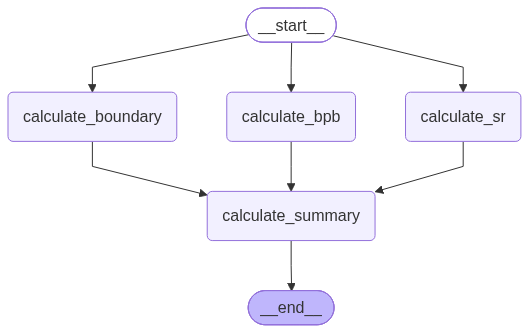

In [8]:
workflow

In [9]:
initial_state= {
    'runs' : 100,
    'balls' :50,
    'four' : 6,
    'sixes' :4
    
}

In [10]:
workflow.invoke( initial_state)

{'runs': 100,
 'balls': 50,
 'four': 6,
 'sixes': 4,
 'sr': 200.0,
 'bpb': 0.2,
 'boundary': 48.0}